# Fig 3

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy
import pingouin as pg

from scipy.stats import zscore

import src.stat_utils as ssu
import src.distance_utils as sdu
import src.stat_test_utils as stu
import src.graph_utils as sgu
import src.plot_analysis as spa
import src.annot_plot as sap
import src.mixed_model as smm
import src.augment_data as sad

from src.config import PATHS

In [2]:
%load_ext autoreload
%autoreload 2

## Load Data

In [3]:
core_dt_all, task1_dt_all, task2_dt_all, task3_dt_all, task4_dt_all, task3_4_dt_all = sad.load_full_data(
    excl_incompl=True,
    excl_cheaters=True,
    excl_uncertains=True,
    verbose=0,
)

In [4]:
core_dt = core_dt_all
task1_dt  = task1_dt_all
task1_dt = task1_dt_all
task2_dt = task2_dt_all
task3_dt = task3_dt_all
task4_dt = task4_dt_all
task3_4_dt = task3_4_dt_all

In [5]:
task3_dt_rot = task3_dt[task3_dt["var_type"] == "rotational"]

## Panel a: Accuracy (Probe)

In [6]:
task2_rot = task2_dt[task2_dt["var_type"] == "rotational"]

/home/tk/01_PROJECTS/archive_exp_cogn_graphs/src/plot_analysis.py:130: UserWarning: The palette list has more values (2) than needed (1), which may not be intended.
  sns.pointplot(
/home/tk/01_PROJECTS/archive_exp_cogn_graphs/src/plot_analysis.py:138: UserWarning: The palette list has more values (2) than needed (1), which may not be intended.
  sns.stripplot(


(0.0, 1.18)

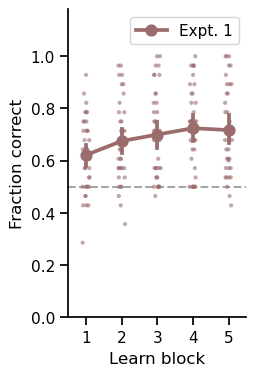

In [7]:
fig, axs = plt.subplots(1,1, figsize=(2.3,4))
spa.axplot_task2_paired(task2_rot, "acc_learnrelquest", hline=0.5,)
axs.set_ylim([0,1.18])

              T  dof alternative         p-val         CI95%   cohen-d  \
T-test  9.99603   39   two-sided  2.587880e-12  [0.65, 0.72]  1.580511   

            BF10  power  
T-test  3.33e+09    1.0  


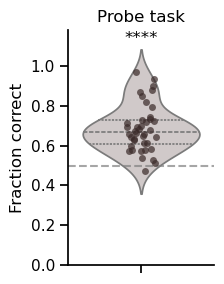

In [8]:
fig, axs = plt.subplots(1,1, figsize=(2.4,3.))
spa.axplot_task2_all(
    task2_rot, key="acc_learnrelquest", 
    color=["#D1C8C8", "#3A2A29"], verbose=3, ax=axs)
axs.set_title("Probe task")
fig.tight_layout()

In [9]:
x = task2_rot.groupby("subject_id")["acc_learnrelquest"].mean()
print(x.describe())

count    40.000000
mean      0.686342
std       0.117900
min       0.471429
25%       0.610714
50%       0.667746
75%       0.730357
max       0.971429
Name: acc_learnrelquest, dtype: float64


In [10]:
pg.ttest(task2_rot.groupby("subject_id")["acc_learnrelquest"].mean(), 0)

,T,dof,alternative,p-val,CI95%,cohen-d,BF10,power
T-test,36.817814,39,two-sided,6.588183e-32,"[0.65, 0.72]",5.821407,3.112e+28,1.0


## Panel b: Accuracy (Path-choice)

               T  dof alternative     p-val         CI95%   cohen-d     BF10  \
T-test  4.048715   39   two-sided  0.000237  [0.55, 0.64]  0.640158  111.295   

           power  
T-test  0.976549  


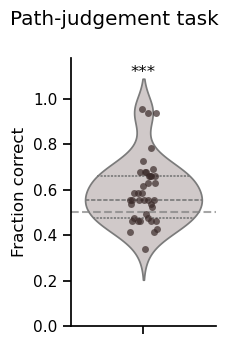

In [11]:
fig, axs = plt.subplots(1,1, figsize=(2.4,3.5))
spa.axplot_task2_all(task3_dt_rot, key="acc_spd", 
                     color=["#D1C8C8", "#3A2A29"],  
                     verbose=1, ax=axs,)
fig.suptitle("Path-judgement task")
fig.tight_layout()
plt.show()

In [12]:
pg.ttest(task3_dt_rot.groupby("subject_id")["acc_spd"].mean(), 0)

,T,dof,alternative,p-val,CI95%,cohen-d,BF10,power
T-test,26.475295,39,two-sided,1.553132e-26,"[0.55, 0.64]",4.186112,1.859e+23,1.0


In [13]:
task3_dt_rot.groupby("subject_id")["acc_spd"].mean().describe()

count    40.000000
mean      0.590266
std       0.141006
min       0.338462
25%       0.476923
50%       0.553846
75%       0.661538
max       0.953846
Name: acc_spd, dtype: float64

## Panel b.extra (Congruency task)

/home/tk/01_PROJECTS/archive_exp_cogn_graphs/src/plot_analysis.py:39: SyntaxWarning: invalid escape sequence '\D'
  """
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.



acc: Paired 1-sided t-test: t(39) = 1.64, p = 0.054; Cohen's d = 0.31

acc: two-sided t-test against chance (0.50): t(39) = 4.4852, p = 0.0001

acc: two-sided t-test against chance (0.50): t(39) = 2.0160, p = 0.0507


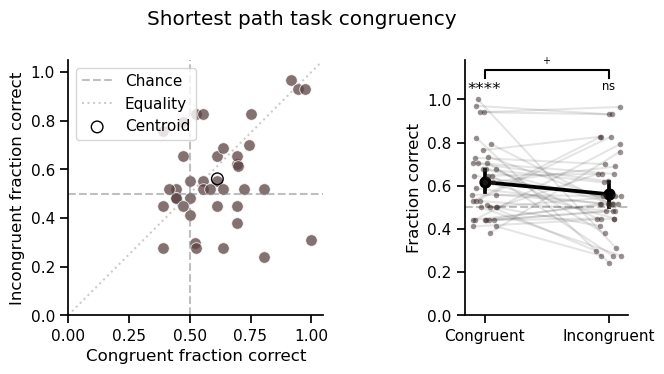

In [24]:
import matplotlib.gridspec as gridspec

congr_type = "eucd_congr"
acc_method = "acc_spd"
dt = task3_dt_rot

fig = plt.figure(figsize=(7.5, 3.8))
gs = gridspec.GridSpec(1, 2, width_ratios=[3, 1])
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])

labels = spa.axplot_2d_congr_kM_clustering(dt, acc_method, congr_type, k=1, ax=ax1)
labels["labels"] = 0
spa.axplot_task3_box_congr(dt, acc_method, congr_type, verbose=1, ax=ax2)

ax1.set_title("")
ax2.set_title("")
ax2.set_xticks([0,1])
ax2.set_xticklabels(["Congruent", "Incongruent"])
ax2.set_ylabel("Fraction correct")
fig.suptitle("Shortest path task congruency")
fig.tight_layout()

In [25]:
# ACC
task3_congr = task3_dt_rot.query("eucd_congr == 1").groupby("subject_id")[["rt_congrtest", "acc_spd"]].mean().reset_index()
task3_incongr = task3_dt_rot.query("eucd_congr == 0").groupby("subject_id")[["rt_congrtest", "acc_spd"]].mean().reset_index()
x = task3_congr.groupby("subject_id")["acc_spd"].mean()
y = task3_incongr.groupby("subject_id")["acc_spd"].mean()
ttest = pg.ttest(x, y, paired=True, r=0.707, alternative="greater") 
print(stu.stat_report(ttest))
ttest

$t(39) = 1.64$, $p = 0.054$, $	ext{BF}_{10} = 1.17$, $d = 0.31$


,T,dof,alternative,p-val,CI95%,cohen-d,BF10,power
T-test,1.643889,39,greater,0.054119,"[-0.0, inf]",0.313788,1.17,0.619857


In [26]:
x.describe()["mean"], y.describe()["mean"]

(0.617091133463161, 0.5610067029894615)

In [27]:
pg.ttest(x, 0)

,T,dof,alternative,p-val,CI95%,cohen-d,BF10,power
T-test,23.637863,39,two-sided,1.002736e-24,"[0.56, 0.67]",3.737474,3.246e+21,1.0


In [28]:
pg.ttest(y, 0)

,T,dof,alternative,p-val,CI95%,cohen-d,BF10,power
T-test,18.538615,39,two-sided,6.112625e-21,"[0.5, 0.62]",2.931212,6.919e+17,1.0


In [29]:
# RT
x = task3_congr.groupby("subject_id")["rt_congrtest"].mean()
y = task3_incongr.groupby("subject_id")["rt_congrtest"].mean()
ttest = pg.ttest(x, y, paired=True, r=0.707) 
print(stu.stat_report(ttest))
ttest

$t(39) = -0.03$, $p = 0.976$, $	ext{BF}_{10} = 0.17$, $d = 0.00$


,T,dof,alternative,p-val,CI95%,cohen-d,BF10,power
T-test,-0.030574,39,two-sided,0.975766,"[-2.35, 2.28]",0.004545,0.171,0.05009


## Panel d: Per-participant correlations (Arena)

In [30]:
task4_dt_rot = task4_dt.query("var_type == 'rotational'")
task3_4_dt_rot = task3_4_dt.query("var_type == 'rotational'")

subj_not_connect = sad.subjects_not_connect(task3_4_dt_rot)
task4_dt_rot = task4_dt_rot[~task4_dt_rot["subject_id"].isin(subj_not_connect)]

mm4_dt_rot = smm.prepare_mm4_dt(task4_dt_rot, zscore_flag=False)

In [31]:
def get_corr_df(
    df, var_type,
    key1="subj_eucd_m_flat", key2="subj_spd_m_flat",
    corr_method="spearman",
    ):
    df =  (
        df.groupby("subject_id")[[key2, key1]]
          .corr(method=corr_method)
          .reset_index()
          .query(f"level_1 == @key1 and {key2} != 1.0")
          .assign(var_type=var_type)
          .rename(columns={key2: "subj_corr"})
          .drop(columns=["level_1", key1])
    )
    
    return df

0: ρ=0.35, 95% CI [0.09 0.37], T(32)=3.30, p = 0.002, d=0.58
1: ρ=0.27, 95% CI [0.13 0.34], T(31)=4.39, p < .001, d=0.78
2: ρ=0.04, 95% CI [-0.04  0.11], T(32)=1.05, p = 0.301, d=0.18
3: ρ=0.10, 95% CI [-0.02  0.16], T(32)=1.57, p = 0.127, d=0.27
4: ρ=0.43, 95% CI [0.23 0.46], T(32)=6.27, p < .001, d=1.09
Normality check 1: False
Normality check 2: True
Normality check 3: False
Normality check 4: False
Difference (1 vs 2):                T        dof alternative     p-val         CI95%   cohen-d  \
T-test  3.115122  48.554083   two-sided  0.003083  [0.08, 0.39]  0.779146   

          BF10     power  
T-test  13.184  0.871242  
Difference (3 vs 4):                T  dof alternative     p-val           CI95%   cohen-d    BF10  \
T-test -3.026961   64   two-sided  0.003557  [-0.58, -0.12]  0.745186  10.706   

           power  
T-test  0.846439  


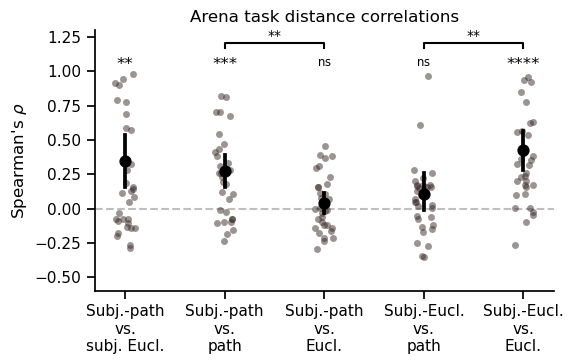

In [32]:
# Correlation method
corr_method = "spearman"

subj_subj_corrs = get_corr_df(mm4_dt_rot, 0, key1="subj_spd_m_flat", key2="subj_eucd_m_flat", corr_method=corr_method)

# Compute correlation DataFrames for subjective path distances
subj_path_corrs = pd.concat([
    get_corr_df(mm4_dt_rot, "1", key1="subj_spd_m_flat", key2="spd_m_flat", corr_method=corr_method),
    get_corr_df(mm4_dt_rot, "2", key1="subj_spd_m_flat", key2="eucd_m_flat", corr_method=corr_method)
], ignore_index=True)

# Compute correlation DataFrames for subjective Euclidean distances
subj_eucl_corrs = pd.concat([
    get_corr_df(mm4_dt_rot, "1", key1="subj_eucd_m_flat", key2="spd_m_flat", corr_method=corr_method),
    get_corr_df(mm4_dt_rot, "2", key1="subj_eucd_m_flat", key2="eucd_m_flat", corr_method=corr_method)
], ignore_index=True)

# Ensure 'var_type' column is numeric
subj_path_corrs['var_type'] = pd.to_numeric(subj_path_corrs['var_type'], errors='coerce')
subj_eucl_corrs['var_type'] = pd.to_numeric(subj_eucl_corrs['var_type'], errors='coerce')

# Shift var_type for Euclidean correlations so categories don’t overlap
subj_eucl_corrs["var_type"] += 2

# Combine both DataFrames
all_corrs = pd.concat([subj_subj_corrs, subj_path_corrs, subj_eucl_corrs])

# Plot setup
fig, ax = plt.subplots(1, 1, figsize=(5.9, 3.8))
ax.axhline(y=0.0, color="grey", linestyle="--", alpha=0.5)

# Plot mean + data points
sns.pointplot(all_corrs, x="var_type", y="subj_corr", color="black",
              estimator=spa.fisher_mean_r,
              n_boot=5000, zorder=9,
              alpha=0.99, linestyle="none", ax=ax)
sns.stripplot(all_corrs, x="var_type", y="subj_corr",
                color="#3A2A29", alpha=0.5, ax=ax)

# ax.set_ylim([-0.5, 1.7])
ax.set_ylim([-0.6, 1.3])

# Define x-axis labels
tick_labels = [
    "Subj.-path\nvs.\nsubj. Eucl.",
    "Subj.-path\nvs.\npath",
    "Subj.-path\nvs.\nEucl.",
    "Subj.-Eucl.\nvs.\npath",
    "Subj.-Eucl.\nvs.\nEucl."
]
ax.set_xticks(range(len(tick_labels)))
ax.set_xticklabels(tick_labels)
ax.set_xlabel("")
ax.set_ylabel(r"Spearman's $\rho$")

# === Significance tests against 0 correlation ===
ttest_subj_path_vs_subj_eucl = pg.ttest(all_corrs.query("var_type == 0")["subj_corr"], 0)
ttest_subj_path_vs_path = pg.ttest(all_corrs.query("var_type == 1")["subj_corr"], 0)
ttest_subj_path_vs_eucl = pg.ttest(all_corrs.query("var_type == 2")["subj_corr"], 0)
ttest_subj_eucl_vs_path = pg.ttest(all_corrs.query("var_type == 3")["subj_corr"], 0)
ttest_subj_eucl_vs_eucl = pg.ttest(all_corrs.query("var_type == 4")["subj_corr"], 0)

pval_subj_path_vs_subj_eucl = ttest_subj_path_vs_subj_eucl["p-val"].iloc[0]
pval_subj_path_vs_path = ttest_subj_path_vs_path["p-val"].iloc[0]
pval_subj_path_vs_eucl = ttest_subj_path_vs_eucl["p-val"].iloc[0]
pval_subj_eucl_vs_path = ttest_subj_eucl_vs_path["p-val"].iloc[0]
pval_subj_eucl_vs_eucl = ttest_subj_eucl_vs_eucl["p-val"].iloc[0]

mean_0 = spa.fisher_mean_r(all_corrs.query('var_type == 0')['subj_corr'])
mean_1 = spa.fisher_mean_r(all_corrs.query('var_type == 1')['subj_corr'])
mean_2 = spa.fisher_mean_r(all_corrs.query('var_type == 2')['subj_corr'])
mean_3 = spa.fisher_mean_r(all_corrs.query('var_type == 3')['subj_corr'])
mean_4 = spa.fisher_mean_r(all_corrs.query('var_type == 4')['subj_corr'])

means = [mean_0, mean_1, mean_2, mean_3, mean_4]
tests = [ ttest_subj_path_vs_subj_eucl, ttest_subj_path_vs_path, ttest_subj_path_vs_eucl, ttest_subj_eucl_vs_path, ttest_subj_eucl_vs_eucl ]
pvals = [ pval_subj_path_vs_subj_eucl, pval_subj_path_vs_path, pval_subj_path_vs_eucl, pval_subj_eucl_vs_path, pval_subj_eucl_vs_eucl ]
for i, (mean_val, test, pval) in enumerate(zip(means, tests, pvals)):
    ci = test["CI95%"].iloc[0]
    tval = test["T"].iloc[0]
    dof = test["dof"].iloc[0]
    d = test["cohen-d"].iloc[0]
    print(
        rf'{i}: ρ={mean_val:.2f}, 95% CI {ci}, '
        rf'T({dof})={tval:.2f}, {stu.format_p(pval)}, '
        rf'd={d:.2f}'
    )

sap.annot_stat_bar(sap.calc_stars(pval_subj_path_vs_subj_eucl), 0, 1.05, ax=ax)
sap.annot_stat_bar(sap.calc_stars(pval_subj_path_vs_path), 1, 1.05, ax=ax)
sap.annot_stat_bar(sap.calc_stars(pval_subj_path_vs_eucl), 2, 1.05, ax=ax)
sap.annot_stat_bar(sap.calc_stars(pval_subj_eucl_vs_path), 3, 1.05, ax=ax)
sap.annot_stat_bar(sap.calc_stars(pval_subj_eucl_vs_eucl), 4, 1.05, ax=ax)

# === Group comparisons ===
# Subj.-path vs path  vs  subj.-path vs Eucl. (Fisher z transform)
corrs_1 = ssu.fisher_z(all_corrs.query("var_type == 1")['subj_corr'])
corr_2 = ssu.fisher_z(all_corrs.query("var_type == 2")['subj_corr'])
# Subj.-Eucl. vs path  vs  subj.-Eucl. vs Eucl. (Fisher z transform)
corr_3 = ssu.fisher_z(all_corrs.query("var_type == 3")['subj_corr'])
corr_4 = ssu.fisher_z(all_corrs.query("var_type == 4")['subj_corr'])

ttest_path = pg.ttest(corrs_1, corr_2)
# print(f"Normality check 0: {pg.normality(corrs_0)['normal'].iloc[0]}")
print(f"Normality check 1: {pg.normality(corrs_1)['normal'].iloc[0]}")
print(f"Normality check 2: {pg.normality(corr_2)['normal'].iloc[0]}")
print(f"Normality check 3: {pg.normality(corr_3)['normal'].iloc[0]}")
print(f"Normality check 4: {pg.normality(corr_4)['normal'].iloc[0]}")

print("Difference (1 vs 2):", ttest_path)

sap.annot_stat(sap.calc_stars(ttest_path["p-val"].iloc[0]), 1, 2, 1.17, ax=ax)

ttest_eucl = pg.ttest(corr_3, corr_4)

print("Difference (3 vs 4):", ttest_eucl)

sap.annot_stat(sap.calc_stars(ttest_eucl["p-val"].iloc[0]), 3, 4, 1.17, ax=ax)

# Figure
ax.set_title("Arena task distance correlations")
fig.tight_layout()
plt.show()


## Panel c: Path-choice prediction from true distances

In [33]:
task3_4_rot = task3_4_dt.query("var_type == 'rotational'")
mm3_rot = smm.prepare_mm3_dt(task3_4_rot, zscore_flag=True)

### Model 1

boundary (singular) fit: see help('isSingular') 

Linear mixed model fit by maximum likelihood  ['lmerMod']
Formula: response~spd_pp_diff+eucd_pp_diff+color_pp_diff+(1|subject_id)

Family: binomial	 Inference: parametric

Number of observations: 2617	 Groups: {'subject_id': 40.0}

Log-likelihood: -1764.457 	 AIC: 3538.914

Random effects:

                   Name  Var  Std
subject_id  (Intercept)  0.0  0.0

No random effect correlations specified

Fixed effects:



/home/tk/miniconda3/envs/archive_graph_exp/lib/python3.12/site-packages/pymer4/models/Lmer.py:733: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  ran_vars = ran_vars.applymap(
/home/tk/01_PROJECTS/archive_exp_cogn_graphs/src/plot_analysis.py:371: UserWarning: The palette list has more values (10) than needed (3), which may not be intended.
  sns.barplot(y="value", x="predictor", hue="predictor", data=effects,


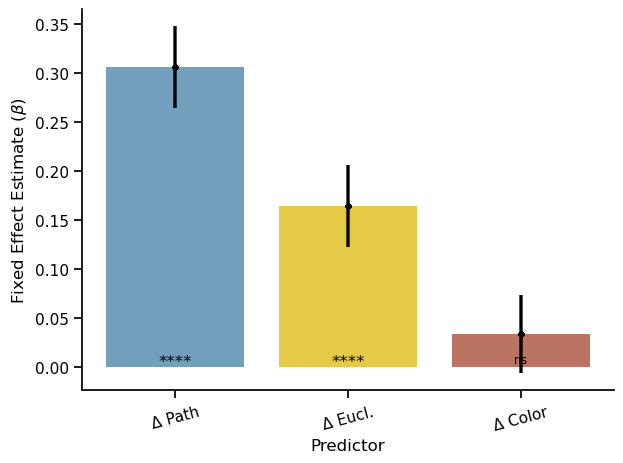

Corr. of true and gen data: spearm=0.19, p_val=0.0000


In [34]:
true_predictors = [
    'spd_pp_diff', 
    "eucd_pp_diff",
    "color_pp_diff",
]
dt = mm3_rot
# dt = mm3_rot[~mm3_rot["subject_id"].isin(sad.subjects_not_connect(mm3_rot, mm3=True))].copy()

model_true, results_true = smm.run_mixed_model(
    dt, true_predictors, plotting=1, 
    )

In [35]:
model = model_true

f"Family: {model.family}, Inference: {model.AIC:.2f}"
f"Number observations: {model.logLike:.2f}, AIC: {model.AIC:.2f}"
f"Log-likelihood: {model.logLike:.2f}, AIC: {model.AIC:.2f}"
# Also correlation with true and gen data?

'Log-likelihood: -1764.46, AIC: 3538.91'

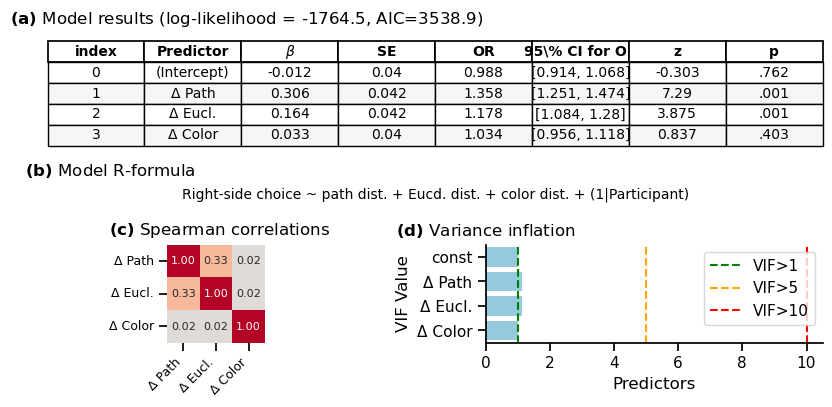

In [36]:
fig = smm.plot_model_specs(mm3_rot, results_true, model_true)
plt.show()

In [37]:
res = results_true
smm.mm_results_to_latex(res, printing=True,)

cols = res.index.drop("(Intercept)")
vif_data = ssu.calc_vif(dt[cols])
print(smm.df_to_vif_latex(
    vif_data,
    caption="SX. Table. Model ? VIF", label="tab:vif"
))

\begin{table}
\caption{TBC}
\label{tab:mm}
\begin{tabular}{lrrrlrl}
\hline
Predictor & $\beta$ & SE & z & p & OR & 95\% CI for OR \\
\hline
(Intercept) & -0.01 & 0.04 & -0.30 & .762 & 0.99 & [0.914, 1.068] \\
$\Delta$ Path & 0.31 & 0.04 & 7.29 & .001 & 1.36 & [1.251, 1.474] \\
$\Delta$ Eucl. & 0.16 & 0.04 & 3.88 & .001 & 1.18 & [1.084, 1.28] \\
$\Delta$ Color & 0.03 & 0.04 & 0.84 & .403 & 1.03 & [0.956, 1.118] \\
\hline
\end{tabular}
\end{table}

\begin{table}[h!]
\centering
\footnotesize
\renewcommand{\arraystretch}{1.2}
\caption*{\textbf{SX. Table. Model ? VIF}}
\begin{tabular}{l c}
\hline
\textbf{Predictor} & \textbf{VIF} \\
\hline
\makecell[l]{$\Delta$ Path} & 1.126 \\
\makecell[l]{$\Delta$ Eucl.} & 1.126 \\
\makecell[l]{$\Delta$ Color} & 1.001 \\
\hline
\end{tabular}
\end{table}


### Model 2

boundary (singular) fit: see help('isSingular') 

Linear mixed model fit by maximum likelihood  ['lmerMod']
Formula: response~spd_pp_diff+eucd_pp_diff+color_pp_diff+(1|subject_id)

Family: binomial	 Inference: parametric

Number of observations: 2162	 Groups: {'subject_id': 33.0}

Log-likelihood: -1442.522 	 AIC: 2895.044

Random effects:

                   Name  Var  Std
subject_id  (Intercept)  0.0  0.0

No random effect correlations specified

Fixed effects:



/home/tk/miniconda3/envs/archive_graph_exp/lib/python3.12/site-packages/pymer4/models/Lmer.py:733: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  ran_vars = ran_vars.applymap(
/home/tk/01_PROJECTS/archive_exp_cogn_graphs/src/plot_analysis.py:371: UserWarning: The palette list has more values (10) than needed (3), which may not be intended.
  sns.barplot(y="value", x="predictor", hue="predictor", data=effects,


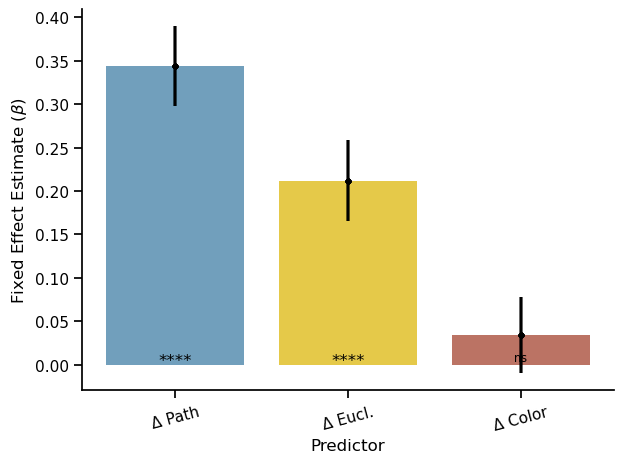

Corr. of true and gen data: spearm=0.22, p_val=0.0000


In [38]:
true_predictors = [
    'spd_pp_diff', 
    "eucd_pp_diff",
    "color_pp_diff",
]
dt = mm3_rot[~mm3_rot["subject_id"].isin(sad.subjects_not_connect(mm3_rot, mm3=True))].copy()

model_true, results_true = smm.run_mixed_model(
    dt, true_predictors, plotting=1, 
    )

### Model 3

boundary (singular) fit: see help('isSingular') 

Linear mixed model fit by maximum likelihood  ['lmerMod']
Formula: response~subj_spd_pp_diff+subj_eucd_pp_diff+color_pp_diff+(1|subject_id)

Family: binomial	 Inference: parametric

Number of observations: 2162	 Groups: {'subject_id': 33.0}

Log-likelihood: -1482.879 	 AIC: 2975.757

Random effects:

                   Name  Var  Std
subject_id  (Intercept)  0.0  0.0

No random effect correlations specified

Fixed effects:



/home/tk/miniconda3/envs/archive_graph_exp/lib/python3.12/site-packages/pymer4/models/Lmer.py:733: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  ran_vars = ran_vars.applymap(
/home/tk/01_PROJECTS/archive_exp_cogn_graphs/src/plot_analysis.py:371: UserWarning: The palette list has more values (10) than needed (3), which may not be intended.
  sns.barplot(y="value", x="predictor", hue="predictor", data=effects,


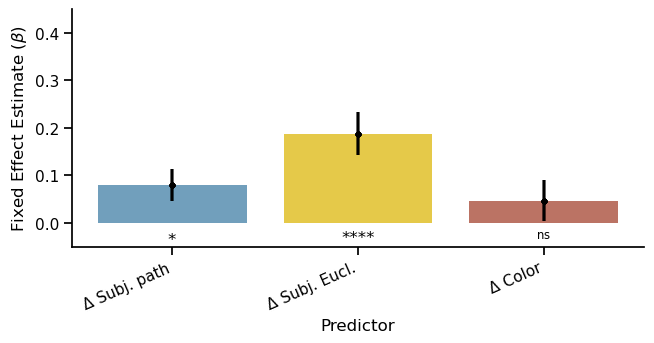

In [39]:
subj_predictors = [
    'subj_spd_pp_diff',
    'subj_eucd_pp_diff',
    "color_pp_diff",
]

# Exclude 7 subjects that didn't connect the graph compltely
dt = mm3_rot[~mm3_rot["subject_id"].isin(sad.subjects_not_connect(mm3_rot, mm3=True))].copy()

model_subj, results_subj = smm.run_mixed_model(
    dt, subj_predictors, plotting=0, 
    )

fig, axs = plt.subplots(1, 1, figsize=(6.7,3.6))
spa.axplot_fixed_effects(
    model_subj.fixef,
    errors=results_subj["SE"],
    p_vals=results_subj["P-val"],
    p_val_pos=-0.03,
    label_rotation=24,
    label_ha="right",
    skip_eucd=False,
    skip_wspd=False,
    ax=axs,
)
axs.set_ylim([-0.05, 0.45])
fig.tight_layout()

In [40]:
res = results_subj
smm.mm_results_to_latex(res, printing=True,)

cols = results_subj.index.drop("(Intercept)")
vif_data = ssu.calc_vif(dt[cols])
print(smm.df_to_vif_latex(
    vif_data,
    caption="SX. Table. Model ? VIF", label="tab:vif"
))

\begin{table}
\caption{TBC}
\label{tab:mm}
\begin{tabular}{lrrrlrl}
\hline
Predictor & $\beta$ & SE & z & p & OR & 95\% CI for OR \\
\hline
(Intercept) & -0.03 & 0.04 & -0.74 & .461 & 0.97 & [0.89, 1.054] \\
$\Delta$ Subj. path & 0.08 & 0.03 & 2.46 & .014 & 1.08 & [1.016, 1.155] \\
$\Delta$ Subj. Eucl. & 0.19 & 0.04 & 4.15 & .001 & 1.21 & [1.104, 1.318] \\
$\Delta$ Color & 0.05 & 0.04 & 1.09 & .277 & 1.05 & [0.963, 1.141] \\
\hline
\end{tabular}
\end{table}

\begin{table}[h!]
\centering
\footnotesize
\renewcommand{\arraystretch}{1.2}
\caption*{\textbf{SX. Table. Model ? VIF}}
\begin{tabular}{l c}
\hline
\textbf{Predictor} & \textbf{VIF} \\
\hline
\makecell[l]{$\Delta$ Subj. path} & 1.047 \\
\makecell[l]{$\Delta$ Subj. Eucl.} & 1.042 \\
\makecell[l]{$\Delta$ Color} & 1.011 \\
\hline
\end{tabular}
\end{table}


### Model 4

boundary (singular) fit: see help('isSingular') 

Linear mixed model fit by maximum likelihood  ['lmerMod']
Formula: response~spd_pp_diff+subj_spd_pp_diff+eucd_pp_diff+subj_eucd_pp_diff+color_pp_diff+(1|subject_id)

Family: binomial	 Inference: parametric

Number of observations: 2162	 Groups: {'subject_id': 33.0}

Log-likelihood: -1436.763 	 AIC: 2887.526

Random effects:

                   Name  Var  Std
subject_id  (Intercept)  0.0  0.0

No random effect correlations specified

Fixed effects:



/home/tk/miniconda3/envs/archive_graph_exp/lib/python3.12/site-packages/pymer4/models/Lmer.py:733: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  ran_vars = ran_vars.applymap(
/home/tk/01_PROJECTS/archive_exp_cogn_graphs/src/plot_analysis.py:371: UserWarning: The palette list has more values (12) than needed (5), which may not be intended.
  sns.barplot(y="value", x="predictor", hue="predictor", data=effects,


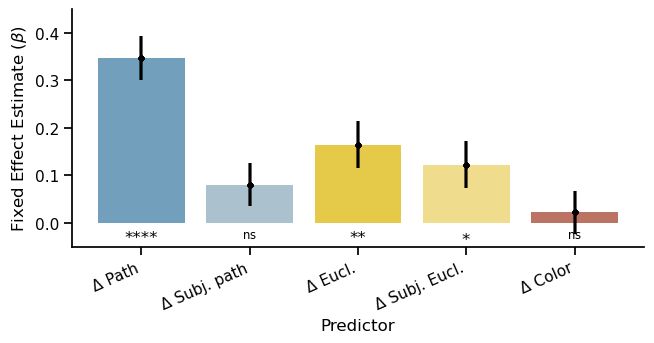

In [41]:
subj_predictors = [
    'spd_pp_diff',
    "subj_spd_pp_diff",
    "eucd_pp_diff", 
    'subj_eucd_pp_diff',
    "color_pp_diff",
]

# Exclude 7 subjects that didn't connect the graph compltely
dt = mm3_rot[~mm3_rot["subject_id"].isin(sad.subjects_not_connect(mm3_rot, mm3=True))].copy()

dt["subj_spd_subt_pp_diff"] = dt["subj_spd_pp_diff"] - dt["spd_pp_diff"]
dt["subj_eucd_subt_pp_diff"] = dt["subj_eucd_pp_diff"] - dt["eucd_pp_diff"]

pp_diff_cols = [c for c in dt.columns if c.endswith("pp_diff") and c != "subj_eucd_prime_pp_diff"]
for col in pp_diff_cols:
    dt.loc[:, col] = sad.zscore(dt[col])

model_subj, results_subj = smm.run_mixed_model(
    dt, subj_predictors, plotting=0, 
    rand_slope=False,
    )


fig, axs = plt.subplots(1, 1, figsize=(6.7,3.6))
spa.axplot_fixed_effects(
    model_subj.fixef,
    errors=results_subj["SE"],
    p_vals=results_subj["P-val"],
    p_val_pos=-0.03,
    label_rotation=24,
    label_ha="right",
    skip_eucd=False,
    skip_wspd=False,
    ax=axs,
)
axs.set_ylim([-0.05, 0.45])
fig.tight_layout()

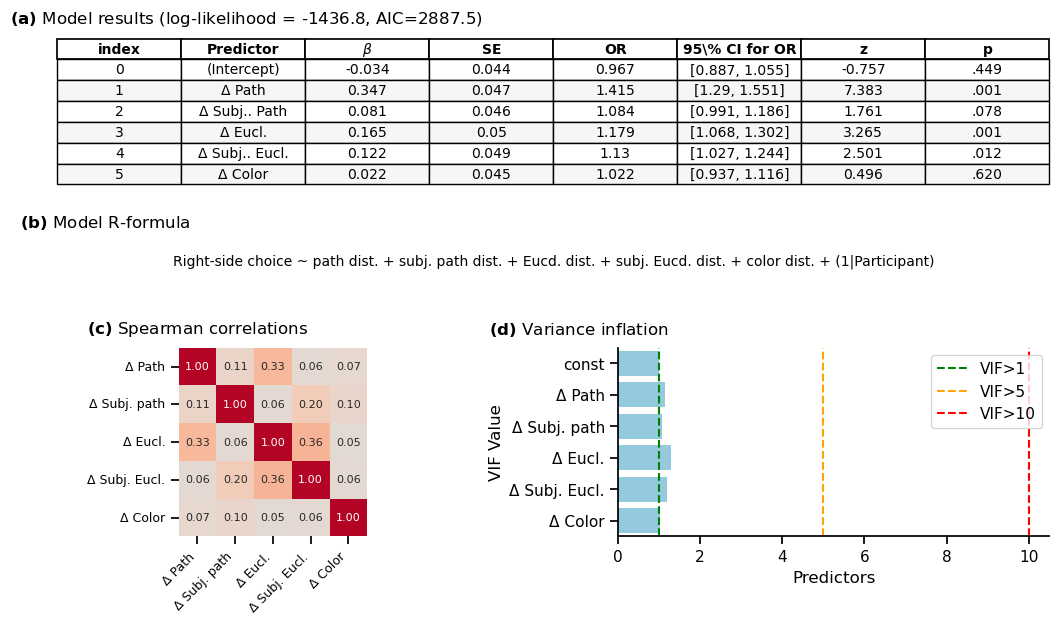

: 

: 

In [ ]:
fig = smm.plot_model_specs(dt, results_subj, model_subj, height_ratios=[0.8, 0.35, 1], fig_size=(12.8, 6.5))
plt.show()

In [42]:
res = results_subj
smm.mm_results_to_latex(res, printing=True,)

cols = results_subj.index.drop("(Intercept)")
vif_data = ssu.calc_vif(dt[cols])
print(smm.df_to_vif_latex(
    vif_data,
    caption="SX. Table. Model ? VIF", label="tab:vif"
))

\begin{table}
\caption{TBC}
\label{tab:mm}
\begin{tabular}{lrrrlrl}
\hline
Predictor & $\beta$ & SE & z & p & OR & 95\% CI for OR \\
\hline
(Intercept) & -0.03 & 0.04 & -0.76 & .449 & 0.97 & [0.887, 1.055] \\
$\Delta$ Path & 0.35 & 0.05 & 7.38 & .001 & 1.42 & [1.29, 1.551] \\
$\Delta$ Subj. path & 0.08 & 0.05 & 1.76 & .078 & 1.08 & [0.991, 1.186] \\
$\Delta$ Eucl. & 0.17 & 0.05 & 3.27 & .001 & 1.18 & [1.068, 1.302] \\
$\Delta$ Subj. Eucl. & 0.12 & 0.05 & 2.50 & .012 & 1.13 & [1.027, 1.244] \\
$\Delta$ Color & 0.02 & 0.04 & 0.50 & .620 & 1.02 & [0.937, 1.116] \\
\hline
\end{tabular}
\end{table}

\begin{table}[h!]
\centering
\footnotesize
\renewcommand{\arraystretch}{1.2}
\caption*{\textbf{SX. Table. Model ? VIF}}
\begin{tabular}{l c}
\hline
\textbf{Predictor} & \textbf{VIF} \\
\hline
\makecell[l]{$\Delta$ Path} & 1.151 \\
\makecell[l]{$\Delta$ Subj. path} & 1.060 \\
\makecell[l]{$\Delta$ Eucl.} & 1.302 \\
\makecell[l]{$\Delta$ Subj. Eucl.} & 1.204 \\
\makecell[l]{$\Delta$ Color} & 1.016

## Panel e: Choice prediction from avg. and specific subjective distances

### Model 6

boundary (singular) fit: see help('isSingular') 

Linear mixed model fit by maximum likelihood  ['lmerMod']
Formula: response~avg_subj_spd_pp_diff+subj_spd_subt_pp_diff+avg_subj_eucd_all_pp_diff+subj_eucd_subt_pp_diff+color_pp_diff+(1|subject_id)

Family: binomial	 Inference: parametric

Number of observations: 2162	 Groups: {'subject_id': 33.0}

Log-likelihood: -1468.902 	 AIC: 2951.804

Random effects:

                   Name  Var  Std
subject_id  (Intercept)  0.0  0.0

No random effect correlations specified

Fixed effects:



/home/tk/miniconda3/envs/archive_graph_exp/lib/python3.12/site-packages/pymer4/models/Lmer.py:733: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  ran_vars = ran_vars.applymap(
/home/tk/01_PROJECTS/archive_exp_cogn_graphs/src/plot_analysis.py:371: UserWarning: The palette list has more values (10) than needed (5), which may not be intended.
  sns.barplot(y="value", x="predictor", hue="predictor", data=effects,


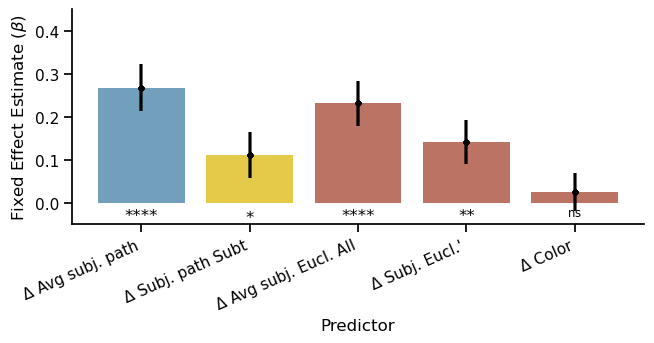

In [43]:
subj_predictors = [
    "avg_subj_spd_pp_diff",
    "subj_spd_subt_pp_diff",
    "avg_subj_eucd_all_pp_diff",
    "subj_eucd_subt_pp_diff",
    "color_pp_diff",
]

# Exclude 7 subjects that didn't connect the graph compltely
dt = mm3_rot[~mm3_rot["subject_id"].isin(sad.subjects_not_connect(mm3_rot, mm3=True))].copy()

dt["subj_spd_subt_pp_diff"] = dt["subj_spd_pp_diff"] - dt["avg_subj_spd_pp_diff"]
dt["subj_eucd_subt_pp_diff"] = dt["subj_eucd_pp_diff"] - dt["avg_subj_eucd_pp_diff"]

pp_diff_cols = [c for c in dt.columns if c.endswith("pp_diff") and c != "subj_eucd_prime_pp_diff"]
for col in pp_diff_cols:
    dt.loc[:, col] = sad.zscore(dt[col])

model_subj, results_subj = smm.run_mixed_model(
    dt, subj_predictors, plotting=0, 
    rand_slope=False,
    )

fig, axs = plt.subplots(1, 1, figsize=(6.7,3.6))
spa.axplot_fixed_effects(
    model_subj.fixef,
    errors=results_subj["SE"],
    p_vals=results_subj["P-val"],
    p_val_pos=-0.03,
    # p_val_pos=1.,
    label_rotation=24,
    label_ha="right",
    skip_eucd=False,
    skip_wspd=False,
    ax=axs,
)
axs.set_ylim([-0.05, 0.45])
fig.tight_layout()

In [ ]:
res = results_subj
smm.mm_results_to_latex(res, printing=True,)

cols = results_subj.index.drop("(Intercept)")
vif_data = ssu.calc_vif(dt[cols])
print(smm.df_to_vif_latex(
    vif_data,
    caption="SX. Table. Model ? VIF", label="tab:vif"
))

\begin{table}
\caption{TBC}
\label{tab:mm}
\begin{tabular}{lrrrlrl}
\hline
Predictor & $\beta$ & SE & z & p & OR & 95\% CI for OR \\
\hline
(Intercept) & -0.03 & 0.04 & -0.74 & .458 & 0.97 & [0.889, 1.055] \\
$\Delta$ Avg subj. path & 0.27 & 0.06 & 4.87 & .001 & 1.31 & [1.173, 1.454] \\
$\Delta$ Subj. path Subt & 0.11 & 0.05 & 2.06 & .040 & 1.12 & [1.005, 1.24] \\
$\Delta$ Avg subj. Eucl. All & 0.23 & 0.05 & 4.48 & .001 & 1.26 & [1.139, 1.394] \\
$\Delta$ Subj. Eucl.' & 0.14 & 0.05 & 2.76 & .006 & 1.15 & [1.042, 1.272] \\
$\Delta$ Color & 0.02 & 0.04 & 0.55 & .586 & 1.02 & [0.939, 1.117] \\
\hline
\end{tabular}
\end{table}

\begin{table}[h!]
\centering
\footnotesize
\renewcommand{\arraystretch}{1.2}
\caption*{\textbf{SX. Table. Model ? VIF}}
\begin{tabular}{l c}
\hline
\textbf{Predictor} & \textbf{VIF} \\
\hline
\makecell[l]{$\Delta$ Avg subj. path} & 1.508 \\
\makecell[l]{$\Delta$ Subj. path Subt} & 1.484 \\
\makecell[l]{$\Delta$ Avg subj. Eucl. All} & 1.371 \\
\makecell[l]{$\Delta$ S

: 

: 

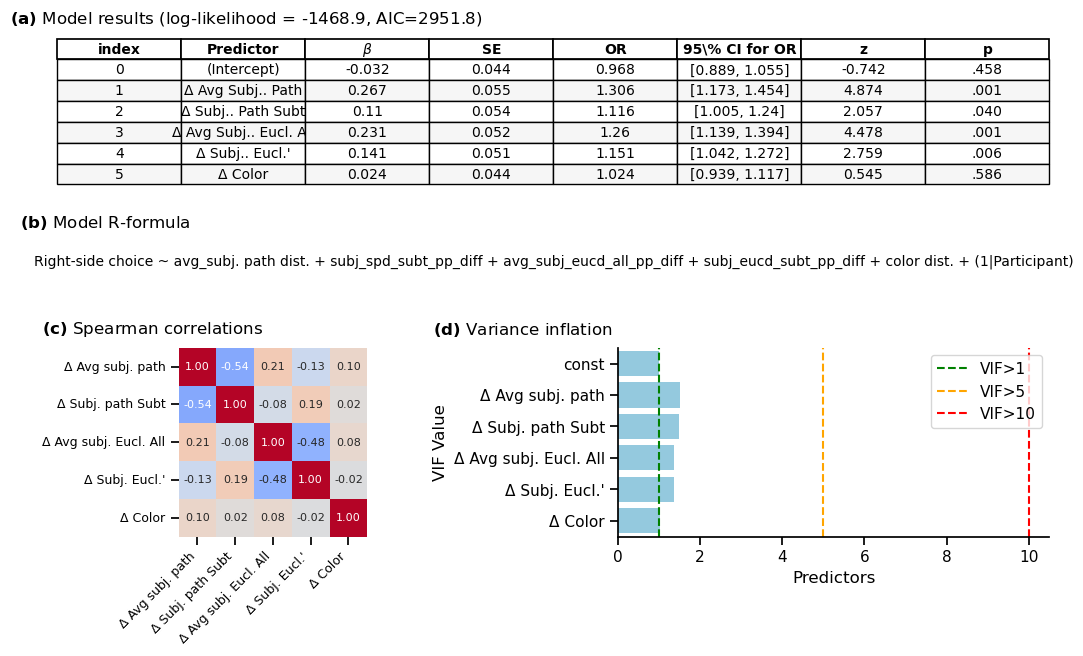

In [44]:
fig = smm.plot_model_specs(dt, results_subj, model_subj, height_ratios=[0.8, 0.35, 1], fig_size=(12.8, 6.5))
plt.show()

## Supplementary 1

### S1L Table: Al Predictor Correlations

In [45]:
dt = mm3_rot.copy()
dt = mm3_rot[~mm3_rot["subject_id"].isin(sad.subjects_not_connect(mm3_rot, mm3=True))].copy()

dt["subj_spd_subt_pp_diff"] = dt["subj_spd_pp_diff"] - dt["avg_subj_spd_pp_diff"]
dt["subj_eucd_subt_pp_diff"] = dt["subj_eucd_pp_diff"] - dt["avg_subj_eucd_pp_diff"]
corr_m =  dt[[
    'spd_pp_diff',
    "avg_subj_spd_pp_diff",
    "subj_spd_pp_diff",
    "subj_spd_subt_pp_diff",
    "eucd_pp_diff", 
    "avg_subj_eucd_pp_diff",
    'subj_eucd_pp_diff',
    "subj_eucd_subt_pp_diff",
    "color_pp_diff",
]].corr(method="spearman")

print(spa.corr_df_to_latex(corr_m))

\begin{table}[h!]
\centering
\scriptsize
\setlength{\tabcolsep}{2pt}
\renewcommand{\arraystretch}{1.1}
\begin{tabular}{lrrrrrrrrr}
\hline
 & \makebox[0pt][l]{\rotatebox[origin=l]{60}{$\Delta$ Path}} & \makebox[0pt][l]{\rotatebox[origin=l]{60}{$\Delta$ Avg subj. path}} & \makebox[0pt][l]{\rotatebox[origin=l]{60}{$\Delta$ Subj. path}} & \makebox[0pt][l]{\rotatebox[origin=l]{60}{$\Delta$ Subj. path Subt}} & \makebox[0pt][l]{\rotatebox[origin=l]{60}{$\Delta$ Eucl.}} & \makebox[0pt][l]{\rotatebox[origin=l]{60}{$\Delta$ Avg subj. Eucl.}} & \makebox[0pt][l]{\rotatebox[origin=l]{60}{$\Delta$ Subj. Eucl.}} & \makebox[0pt][l]{\rotatebox[origin=l]{60}{$\Delta$ Subj. Eucl.'}} & \makebox[0pt][l]{\rotatebox[origin=l]{60}{$\Delta$ Color}} \\
\hline
$\Delta$ Path & 1.00 & 0.60 & 0.15 & -0.27 & 0.31 & 0.03 & 0.05 & 0.02 & 0.07 \\
$\Delta$ Avg subj. path & 0.60 & 1.00 & 0.10 & -0.55 & 0.22 & 0.23 & 0.06 & -0.13 & 0.11 \\
$\Delta$ Subj. path & 0.15 & 0.10 & 1.00 & 0.72 & 0.05 & 0.04 & 0.21 & 0.13 & 0.09 

/home/tk/01_PROJECTS/archive_exp_cogn_graphs/src/plot_analysis.py:631: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_fmt = df.applymap(_fmt)


<Axes: >

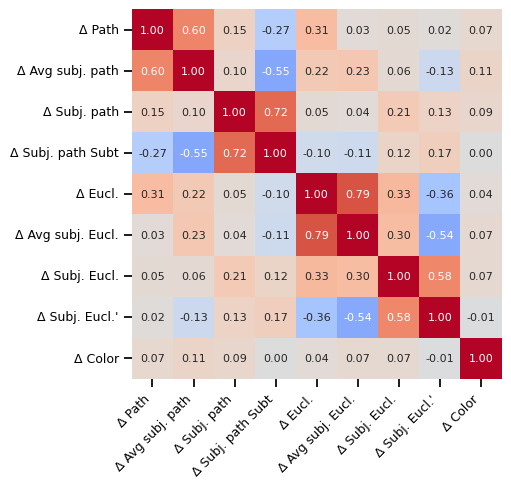

In [46]:
spa.axplot_heatmap(corr_m, labels=spa.format_labels(corr_m.columns))

## Supplementary 2

### Model 2: Predict subjective Eucl. distances (Arena)

In [47]:
# Separate
task4_dt_rot = task4_dt[task4_dt["var_type"]=="rotational"]
task3_4_dt_rot = task3_4_dt[task3_4_dt["var_type"]=="rotational"]
subj_not_connect_rot = sad.subjects_not_connect(task3_4_dt_rot)

task4_dt_rot = task4_dt_rot[~task4_dt_rot["subject_id"].isin(subj_not_connect_rot)].reset_index(drop=True)
mm4_dt_rot = smm.prepare_mm4_dt(task4_dt_rot, zscore_flag=True)

/home/tk/miniconda3/envs/archive_graph_exp/lib/python3.12/site-packages/rpy2/robjects/pandas2ri.py:56: UserWarning: DataFrame contains duplicated elements in the index, which will lead to loss of the row names in the resulting data.frame
  warnings.warn('DataFrame contains duplicated elements in the index, '
/home/tk/miniconda3/envs/archive_graph_exp/lib/python3.12/site-packages/pymer4/models/Lmer.py:733: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  ran_vars = ran_vars.applymap(
/home/tk/01_PROJECTS/archive_exp_cogn_graphs/src/plot_analysis.py:371: UserWarning: The palette list has more values (10) than needed (3), which may not be intended.
  sns.barplot(y="value", x="predictor", hue="predictor", data=effects,


Linear mixed model fit by REML [’lmerMod’]
Formula: subj_eucd_m_flat~spd_m_flat+eucd_m_flat+color_m_flat+(1|subject_id)

Family: gaussian	 Inference: parametric

Number of observations: 924	 Groups: {'subject_id': 33.0}

Log-likelihood: -1113.182 	 AIC: 2238.364

Random effects:

                   Name    Var    Std
subject_id  (Intercept)  0.333  0.577
Residual                 0.579  0.761

No random effect correlations specified

Fixed effects:

Corr. of true and gen data: spearm=0.66, p_val=0.0000


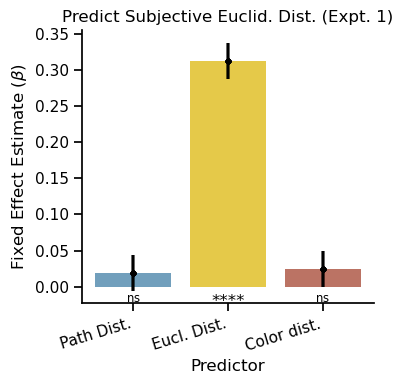

In [48]:
from pymer4.models import Lmer

pos_predictors = [
    'spd_m_flat', 
    'eucd_m_flat',
    'color_m_flat', 
]

# pred_str = [ f'var_type * {s}'for s in pos_predictors]
pred_str = [ f'{s}'for s in pos_predictors]
pred_str = " + ".join(pred_str)

response = "subj_eucd_m_flat"
model = Lmer(f'{response} ~ {pred_str} + (1|subject_id)', data=mm4_dt_rot, family="gaussian", )
results = model.fit()

fig, ax = plt.subplots(1,1, figsize=(4,4))
spa.axplot_fixed_effects(
    model.fixef, errors=results["SE"], p_vals=results["P-val"], 
    p_val_pos=-0.02, ax=ax, label_rotation=17,
    skip_eucd=False, skip_wspd=False,
    label_ha="right",
    )
# ax.set_ylim([-0.14, 0.99])
# ax.set_ylim([-0.03, 0.35])
ax.set_title("Predict Subjective Euclid. Dist. (Expt. 1)")
plt.tight_layout()

# Correlate gen data with true data
corr = scipy.stats.spearmanr(model.fits, mm4_dt_rot[response])
print(f"Corr. of true and gen data: spearm={corr[0]:.2f}, p_val={corr[1]:.4f}")

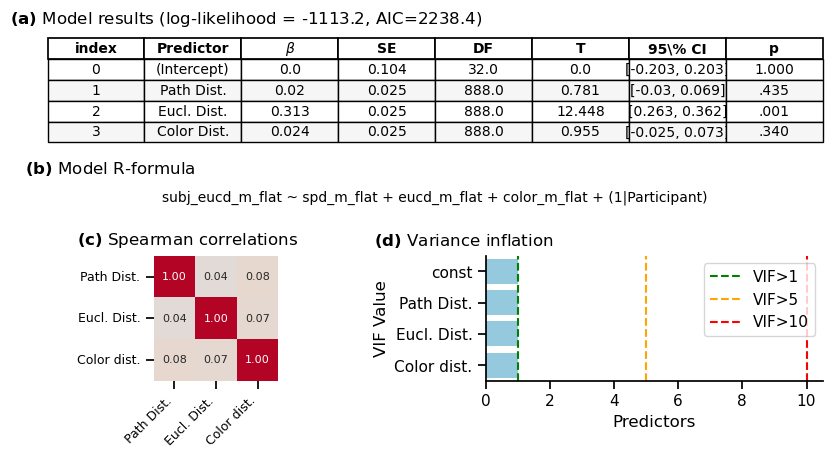

: 

: 

In [ ]:
fig = smm.plot_model_specs(mm4_dt_rot, results, model, height_ratios=[0.9, 0.35, 1], fig_size=(10, 4.5))
plt.show()

In [49]:
res = results
dt = mm4_dt_rot
smm.mm_results_to_latex(res, printing=True,)

cols = res.index.drop("(Intercept)")
vif_data = ssu.calc_vif(dt[cols])
print(smm.df_to_vif_latex(
    vif_data,
    caption="SX. Table. Model ? VIF", label="tab:vif"
))

\begin{table}
\caption{TBC}
\label{tab:mm}
\begin{tabular}{lrrrrll}
\hline
Predictor & $\beta$ & SE & DF & T & p & 95\% CI \\
\hline
(Intercept) & 0.00 & 0.10 & 32.00 & 0.00 & 1.000 & [-0.203, 0.203] \\
Path Dist. & 0.02 & 0.03 & 888.00 & 0.78 & .435 & [-0.03, 0.069] \\
Eucl. Dist. & 0.31 & 0.03 & 888.00 & 12.45 & .001 & [0.263, 0.362] \\
Color dist. & 0.02 & 0.03 & 888.00 & 0.95 & .340 & [-0.025, 0.073] \\
\hline
\end{tabular}
\end{table}

\begin{table}[h!]
\centering
\footnotesize
\renewcommand{\arraystretch}{1.2}
\caption*{\textbf{SX. Table. Model ? VIF}}
\begin{tabular}{l c}
\hline
\textbf{Predictor} & \textbf{VIF} \\
\hline
\makecell[l]{Path Dist.} & 1.007 \\
\makecell[l]{Eucl. Dist.} & 1.006 \\
\makecell[l]{Color dist.} & 1.011 \\
\hline
\end{tabular}
\end{table}


In [50]:
# results_subset_regr_pos.head()

### Model 1: Predict subjective path distances (Arena)

/home/tk/miniconda3/envs/archive_graph_exp/lib/python3.12/site-packages/rpy2/robjects/pandas2ri.py:56: UserWarning: DataFrame contains duplicated elements in the index, which will lead to loss of the row names in the resulting data.frame
  warnings.warn('DataFrame contains duplicated elements in the index, '
/home/tk/miniconda3/envs/archive_graph_exp/lib/python3.12/site-packages/pymer4/models/Lmer.py:733: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  ran_vars = ran_vars.applymap(
/home/tk/01_PROJECTS/archive_exp_cogn_graphs/src/plot_analysis.py:371: UserWarning: The palette list has more values (10) than needed (3), which may not be intended.
  sns.barplot(y="value", x="predictor", hue="predictor", data=effects,


Linear mixed model fit by REML [’lmerMod’]
Formula: subj_spd_m_flat~spd_m_flat+eucd_m_flat+color_m_flat+(1|subject_id)

Family: gaussian	 Inference: parametric

Number of observations: 924	 Groups: {'subject_id': 33.0}

Log-likelihood: -1215.268 	 AIC: 2442.535

Random effects:

                   Name    Var    Std
subject_id  (Intercept)  0.234  0.484
Residual                 0.737  0.858

No random effect correlations specified

Fixed effects:

Corr. of true and gen data: spearm=0.54, p_val=0.0000


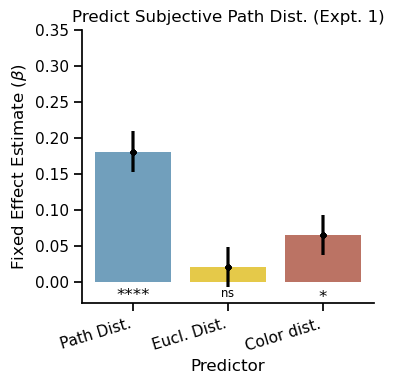

In [51]:
from pymer4.models import Lmer

connect_predictors = [
    'spd_m_flat', 
    'eucd_m_flat',
    'color_m_flat', 
]

# pred_str = [ f'var_type * {s}'for s in pos_predictors]
pred_str = [ f'{s}'for s in connect_predictors]
pred_str = " + ".join(pred_str)

# response = "avg_subj_spd_m_flat"
response = "subj_spd_m_flat"
model = Lmer(f'{response} ~ {pred_str} + (1|subject_id)', data=mm4_dt_rot, family="gaussian", )
results = model.fit()

fig, ax = plt.subplots(1,1, figsize=(4,4))
spa.axplot_fixed_effects(
    model.fixef, errors=results["SE"], p_vals=results["P-val"], 
    p_val_pos=-0.02, ax=ax, label_rotation=17,
    skip_eucd=False, skip_wspd=False,
    label_ha="right",
    )
ax.set_ylim([-0.03, 0.35])
ax.set_title("Predict Subjective Path Dist. (Expt. 1)")
plt.tight_layout()

# Correlate gen data with true data
corr = scipy.stats.spearmanr(model.fits, mm4_dt_rot[response])
print(f"Corr. of true and gen data: spearm={corr[0]:.2f}, p_val={corr[1]:.4f}")

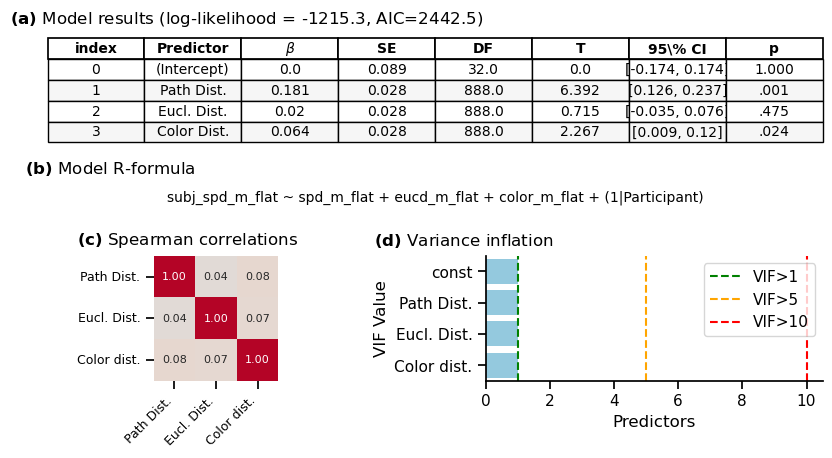

In [52]:
fig = smm.plot_model_specs(mm4_dt_rot, results, model, height_ratios=[0.9, 0.35, 1], fig_size=(10, 4.5))
plt.show()

In [53]:
res = results
dt = mm4_dt_rot
smm.mm_results_to_latex(res, printing=True,)

cols = res.index.drop("(Intercept)")
vif_data = ssu.calc_vif(dt[cols])
print(smm.df_to_vif_latex(
    vif_data,
    caption="SX. Table. Model ? VIF", label="tab:vif"
))

\begin{table}
\caption{TBC}
\label{tab:mm}
\begin{tabular}{lrrrrll}
\hline
Predictor & $\beta$ & SE & DF & T & p & 95\% CI \\
\hline
(Intercept) & 0.00 & 0.09 & 32.00 & 0.00 & 1.000 & [-0.174, 0.174] \\
Path Dist. & 0.18 & 0.03 & 888.00 & 6.39 & .001 & [0.126, 0.237] \\
Eucl. Dist. & 0.02 & 0.03 & 888.00 & 0.71 & .475 & [-0.035, 0.076] \\
Color dist. & 0.06 & 0.03 & 888.00 & 2.27 & .024 & [0.009, 0.12] \\
\hline
\end{tabular}
\end{table}

\begin{table}[h!]
\centering
\footnotesize
\renewcommand{\arraystretch}{1.2}
\caption*{\textbf{SX. Table. Model ? VIF}}
\begin{tabular}{l c}
\hline
\textbf{Predictor} & \textbf{VIF} \\
\hline
\makecell[l]{Path Dist.} & 1.007 \\
\makecell[l]{Eucl. Dist.} & 1.006 \\
\makecell[l]{Color dist.} & 1.011 \\
\hline
\end{tabular}
\end{table}


### All Predictor Correlations

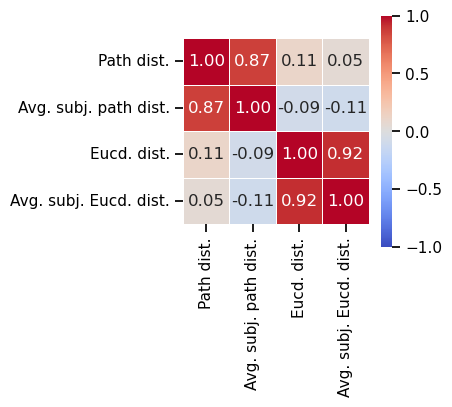

In [54]:
spd_m = task4_dt_rot["spd_m"].iloc[0]
avg_subj_spd_m = task4_dt_rot["avg_subj_spd_m"].iloc[0]
eucd_m = task4_dt_rot['eucd_m'].iloc[0]
avg_subj_eucd_m = task4_dt_rot['avg_subj_eucd_all_m'].iloc[0]

fig, axs = plt.subplots(1, 1, figsize=(3, 3))
x = pd.DataFrame({
    "Path dist.": sgu.get_upper_triangle_without_diagonal(spd_m) ,
    "Avg. subj. path dist.": sgu.get_upper_triangle_without_diagonal(avg_subj_spd_m),
    "Eucd. dist.": sgu.get_upper_triangle_without_diagonal(eucd_m),
    "Avg. subj. Eucd. dist.": sgu.get_upper_triangle_without_diagonal(avg_subj_eucd_m),
})
ssu.plot_corr_matrix(x, method="spearman", vmin=-1, vmax=1, ax=axs, cbar=True)